# CatBoost training and testing

### 1. Introduction


In this notebook, we are going to test and try a CatBoost model.

### 2. Librairies


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt
import joblib

### 3. Load Data, Filter and Pivot to Wide

In [3]:
# 1 : Load
df_long = pd.read_csv('../../Data/dataREanonymized_long.csv')

# 2 : Finding the subjects with non-null discharge_mrs values
valid_subjects = df_long[
    (df_long['variable'] == 'discharge_mrs') &
    (df_long['Value'].notna())
]['subject_id'].unique()

# 3 : Filter the DataFrame to only include valid subjects
df_long_filtered = df_long[df_long['subject_id'].isin(valid_subjects)]

# 4 : Pivot to Wide format
df_wide = df_long_filtered.pivot(index='subject_id', columns='variable', values='Value').reset_index()

# 5 : Keep only rows where stroke_type is "ischemic"
df_wide = df_wide[df_wide['stroke_type'] == 'ischemic']
df_wide = df_wide[df_wide['thrombolysis'] == '1']


C:\Users\2432741\AppData\Local\Temp\ipykernel_12624\1530815583.py:2: DtypeWarning: Columns (0: Value) have mixed types. Specify dtype option on import or set low_memory=False.
  df_long = pd.read_csv('../../Data/dataREanonymized_long.csv')


### 4. Features

In [4]:
# ==========================================
# Creation of a new feature: anticoagulants_discharge
# ==========================================

anticoagulants_during_discharge =  ['discharge_apixaban', 'discharge_dabigatran', 'discharge_edoxaban', 'discharge_rivaroxaban', 'discharge_warfarin', 'discharge_heparin']

df_wide['anticoagulant_discharge'] = df_wide[anticoagulants_during_discharge].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_during_discharge)

In [5]:
# ==========================================
# Creation of a new feature: anticoagulants_before_onset
# ==========================================

anticoagulants_before_onset =  ['before_onset_warfarin']

df_wide['anticoagulant_before_onset'] = df_wide[anticoagulants_before_onset].max(axis=1)

df_wide = df_wide.drop(columns=anticoagulants_before_onset)

In [6]:
# ==========================================
# NIHSS : Three categories: (1) NIHSS<6, (2) 6≤NIHSS<16, (3) NIHSS≥16
# ==========================================

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'], errors='coerce')

limits = [-np.inf, 6, 16, np.inf]
label = [0, 1, 2]

df_wide['nihss_score'] = pd.cut( df_wide['nihss_score'], bins=limits, labels=label, right=False)

df_wide['nihss_score'] = pd.to_numeric(df_wide['nihss_score'],) 

In [7]:
# ==========================================
# Systolic Blood Pressure (SBP, mmHg) 
# Patients treated with IVT and/or EVT
# Three categories: (1) SBP≤110, (2) 110<SBP<180, (3) SBP≥180
# ==========================================

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'], errors='coerce')

limits = [-np.inf, 111, 180, np.inf]
label = [0, 1, 2]

df_wide['sys_blood_pressure'] = pd.cut( df_wide['sys_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['sys_blood_pressure'] = pd.to_numeric(df_wide['sys_blood_pressure'])

In [8]:
# ==========================================
# Diastolic Blood Pressure (DBP, mmHg) 
# Patients treated with IVT and/or EVT
# Two categories: (1) DBP<105, (2) DBP≥105
# ==========================================

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'], errors='coerce')

limits = [-np.inf, 105, np.inf]
label = [0, 1]

df_wide['dis_blood_pressure'] = pd.cut( df_wide['dis_blood_pressure'], bins=limits, labels=label, right=False)

df_wide['dis_blood_pressure'] = pd.to_numeric(df_wide['dis_blood_pressure'])

In [9]:
# ==========================================
# Blood glucose (mg/dl)
# Three categories: (1) glucose<60, (2) 60≤glucose≤140, (3) glucose>140 
# ==========================================

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'], errors='coerce')

limits = [-np.inf, 60, 141, np.inf]
label = [0, 1, 2]

df_wide['glucose'] = pd.cut( df_wide['glucose'], bins=limits, labels=label, right=False)

df_wide['glucose'] = pd.to_numeric(df_wide['glucose'])

In [10]:
# ==========================================
# Cholesterol (LDL-C, mg/dl)
# Three categories: (1) LDL-C<70, (2) 70≤LDL-C≤100, (3) LDL-C>100
# ==========================================

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'], errors='coerce')

limits = [-np.inf, 70, 101, np.inf]
label = [0, 1, 2]

df_wide['cholesterol'] = pd.cut( df_wide['cholesterol'], bins=limits, labels=label, right=False)

df_wide['cholesterol'] = pd.to_numeric(df_wide['cholesterol'])

In [11]:
# ==========================================
# Prestroke mRS
# Three categories: (1) 0≤mRS<2, (2) mRS=2, (3) 2<mRS≤5 
# ==========================================

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'], errors='coerce')

limits = [-np.inf, 2, 3, np.inf]
label = [0, 1, 2]

df_wide['prestroke_mrs'] = pd.cut( df_wide['prestroke_mrs'], bins=limits, labels=label, right=False)

df_wide['prestroke_mrs'] = pd.to_numeric(df_wide['prestroke_mrs'])

In [12]:
# ==========================================
# Onset to door (OTD, hours)
# Patients treated with only IVT
# Three categories: (1) OTD≤4.5, (2) 4.5<OTD≤24, (3) OTD>24  
# ==========================================

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'], errors='coerce')

limits = [-np.inf, 4.5, 24, np.inf]
label = [0, 1, 2]

df_wide['onset_to_door'] = pd.cut( df_wide['onset_to_door'], bins=limits, labels=label, right=True)

df_wide['onset_to_door'] = pd.to_numeric(df_wide['onset_to_door'])

In [13]:
# ==========================================
# Door to imaging (DTI, minutes)
# Two categories: (1) DTI≤20, (2) DTI>20
# ==========================================

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'], errors='coerce')

limits = [-np.inf, 20, np.inf]
label = [0, 1]

df_wide['door_to_imaging'] = pd.cut( df_wide['door_to_imaging'], bins=limits, labels=label, right=True)

df_wide['door_to_imaging'] = pd.to_numeric(df_wide['door_to_imaging'])

In [14]:
# ==========================================
# Door to needle (DTN, minutes)
# Four categories: (1) DTN≤30, (2) 30<DTN≤45, (3) 45<DTN≤60, (4) DTN>60
# ==========================================

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'], errors='coerce')

limits = [-np.inf, 30, 45, 60, np.inf]
label = [0, 1, 2, 3]

df_wide['door_to_needle'] = pd.cut( df_wide['door_to_needle'], bins=limits, labels=label, right=True)

df_wide['door_to_needle'] = pd.to_numeric(df_wide['door_to_needle'])

### 5. Target

In [15]:
target_raw = pd.to_numeric(df_wide['three_m_mrs'], errors='coerce')
valid_target = target_raw.notna()

y = target_raw[valid_target].astype(int)

colonnes_a_jeter = ['discharge_mrs', 'three_m_mrs', 'stroke_type', 'door_to_groin', 'thrombolysis', 'subject_id',
                          'bleeding_source', 'bleeding_volume_value', 'department_type', 'dysphagia_screening_type',
                          'gender', 'hospitalized_in', 'hunt_hess_score', 'ich_score', 'imaging_type', 'no_thrombolysis_reason',
                          'stroke_mimics_diagnosis']
X = df_wide.loc[valid_target].drop(columns=[col for col in colonnes_a_jeter if col in df_wide.columns])

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.dropna(how='all', axis=1)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 6. Train

In [16]:
categorical_candidates = [
    'nihss_score',
    'sys_blood_pressure',
    'dis_blood_pressure',
    'glucose',
    'cholesterol',
    'prestroke_mrs',
    'onset_to_door',
    'door_to_imaging',
    'door_to_needle',
    'anticoagulant_discharge',
    'anticoagulant_before_onset'
]
cat_features_valides = [col for col in categorical_candidates if col in X_train.columns]
num_features = [col for col in X_train.columns if col not in cat_features_valides]

### 7. Imputing

In [17]:
imputer = KNNImputer(n_neighbors=5)

X_train_num_imputed = pd.DataFrame(imputer.fit_transform(X_train[num_features]), columns=num_features, index=X_train.index)
X_test_num_imputed = pd.DataFrame(imputer.transform(X_test[num_features]), columns=num_features, index=X_test.index)

In [18]:
for col in cat_features_valides:
    X_train_num_imputed[col] = X_train[col].fillna(-1).astype(int)
    X_test_num_imputed[col] = X_test[col].fillna(-1).astype(int)

X_train = X_train_num_imputed
X_test = X_test_num_imputed

In [19]:
# 1. Grille de recherche pour trouver les meilleurs réglages du modèle
from sklearn.model_selection import StratifiedKFold

param_grid = {
    'iterations': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8]
}

# 2. Initialisation du modèle 
cb_model = CatBoostRegressor(
    loss_function='RMSE', 
    random_seed=42,
    verbose=0
)

# 3. Entraînement avec recherche des meilleurs paramètres et validation croisée
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_mean_absolute_error', 
    cv=cv,
    verbose=0,
    random_state=42
)

random_search.fit(X_train, y_train, cat_features=cat_features_valides)
best_catboost = random_search.best_estimator_
print(f"Meilleurs paramètres trouvés : {random_search.best_params_}")
print(f"Score d'accuracy moyen obtenu en validation croisée : {random_search.best_score_:.3f}")


Meilleurs paramètres trouvés : {'learning_rate': 0.1, 'iterations': 200, 'depth': 6}
Score d'accuracy moyen obtenu en validation croisée : -1.170


Erreur Moyenne Absolue (MAE) : 1.17 points d'écart en moyenne
Précision stricte (mRS exact) : 41.54%
PRÉCISION CLINIQUE (mRS exact ou ± 1 point) : 72.31%



<Figure size 800x600 with 0 Axes>

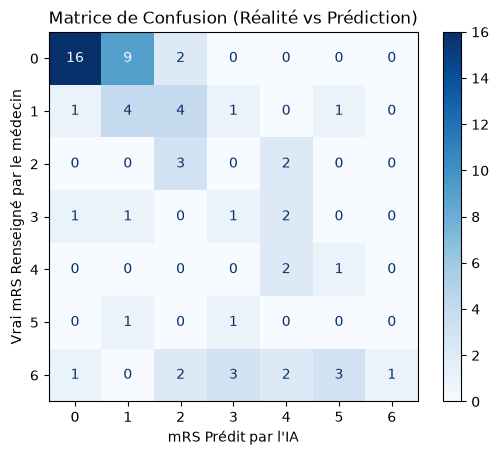

In [20]:
y_pred_raw = best_catboost.predict(X_test)
y_pred_arrondi = np.round(y_pred_raw).clip(0, 6).astype(int)

mae = mean_absolute_error(y_test, y_pred_raw)
accuracy_stricte = accuracy_score(y_test, y_pred_arrondi)
ecarts = np.abs(y_test.values - y_pred_arrondi)
accuracy_plus_moins_1 = np.mean(ecarts <= 1)

print(f"Erreur Moyenne Absolue (MAE) : {mae:.2f} points d'écart en moyenne")
print(f"Précision stricte (mRS exact) : {accuracy_stricte * 100:.2f}%")
print(f"PRÉCISION CLINIQUE (mRS exact ou ± 1 point) : {accuracy_plus_moins_1 * 100:.2f}%\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_arrondi, labels=[0, 1, 2, 3, 4, 5, 6])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4, 5, 6])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de Confusion (Réalité vs Prédiction)")
plt.xlabel("mRS Prédit par l'IA")
plt.ylabel("Vrai mRS Renseigné par le médecin")
plt.show()

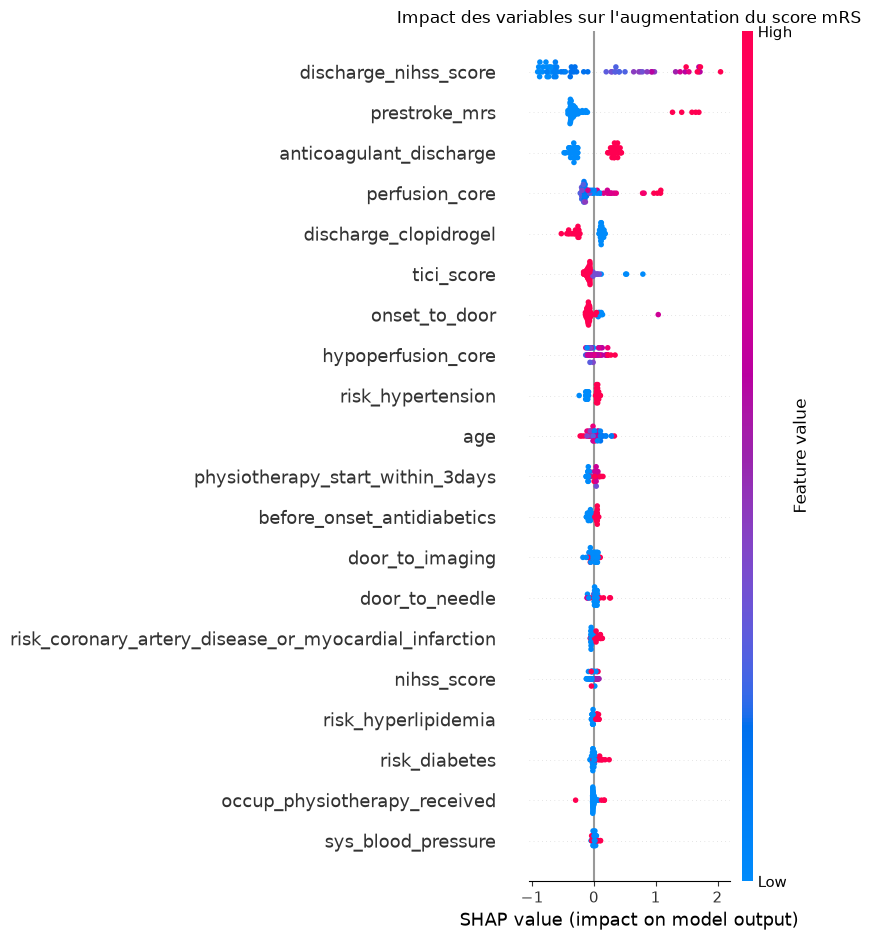


Analyse individuelle des 2 premiers patients du test :

PATIENT TEST N°0
Vrai mRS Renseigné : 0 | mRS Prédit par l'IA : 0


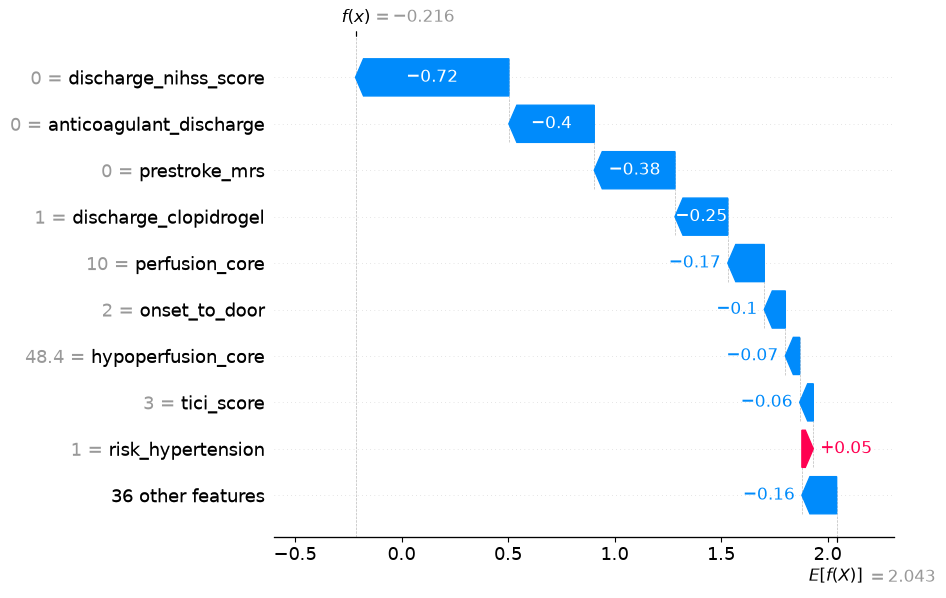


PATIENT TEST N°1
Vrai mRS Renseigné : 0 | mRS Prédit par l'IA : 2


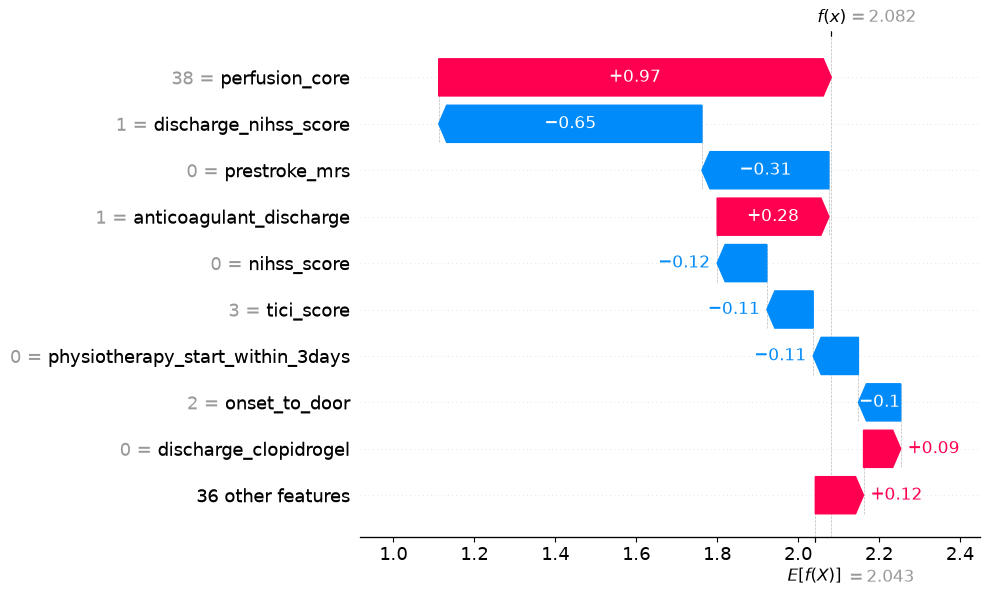

In [21]:
explainer = shap.TreeExplainer(best_catboost)
shap_values = explainer(X_test)
shap_values_legacy = explainer.shap_values(X_test)

# --- SHAP GLOBAL ---
plt.figure(figsize=(10, 6))
plt.title("Impact des variables sur l'augmentation du score mRS")
shap.summary_plot(shap_values_legacy, X_test)
plt.show()

# --- SHAP INDIVIDUEL (Waterfall) ---
print("\nAnalyse individuelle des 2 premiers patients du test :")
nombre_de_patients_a_analyser = 2

for patient_index in range(nombre_de_patients_a_analyser):
    vrai_mrs = y_test.iloc[patient_index]
    mrs_estime = y_pred_arrondi[patient_index]
    mrs_brut = y_pred_raw[patient_index]
    
    print(f"\n==================================================")
    print(f"PATIENT TEST N°{patient_index}")
    print(f"Vrai mRS Renseigné : {vrai_mrs} | mRS Prédit par l'IA : {mrs_estime}")
    print(f"==================================================")
    
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_values[patient_index])
    plt.show()

In [22]:
# 1. Définition stricte : Parfait (écart = 0) vs Faux (tout le reste)
masque_parfaits = (y_test.values == y_pred_arrondi)
masque_faux = (y_test.values != y_pred_arrondi)

# 2. Séparation du jeu de données
X_test_parfaits = X_test[masque_parfaits]
X_test_faux = X_test[masque_faux]

print(f"Patients PARFAITEMENT prédits (Score exact) : {len(X_test_parfaits)}")
print(f"Patients FAUSSEMENT prédits (Toute erreur, même de 1) : {len(X_test_faux)}\n")

# 3. Création du tableau de comparaison (Médianes et Moyennes)
comparaison_df = pd.DataFrame({
    'median (Good ones)': X_test_parfaits.median(),
    'median (wrong ones)': X_test_faux.median(),
    'average (Good ones)': X_test_parfaits.mean(),
    'average (wrong ones)': X_test_faux.mean()
})

# 4. Calcul de l'écart pour repérer ce qui influence les erreurs
comparaison_df['Difference'] = abs(comparaison_df['average (Good ones)'] - comparaison_df['average (wrong ones)'])

# 5. Tri du plus grand écart au plus petit
comparaison_df = comparaison_df.sort_values(by='Difference', ascending=False)

# Affichage propre du tableau
try:
    display(comparaison_df.round(2))
except NameError:
    print(comparaison_df.round(2).to_string())

Patients PARFAITEMENT prédits (Score exact) : 27
Patients FAUSSEMENT prédits (Toute erreur, même de 1) : 38



,median (Good ones),median (wrong ones),average (Good ones),average (wrong ones),Difference
hypoperfusion_core,70.8,84.6,64.50,85.25,20.75
perfusion_core,5.4,10.9,8.94,17.77,8.83
discharge_nihss_score,1.0,3.1,2.56,4.43,1.87
age,73.0,71.0,72.22,70.42,1.80
anticoagulant_discharge,0.0,1.0,0.15,0.71,0.56
risk_diabetes,0.0,0.0,0.07,0.32,0.24
risk_hypertension,1.0,1.0,0.52,0.68,0.17
discharge_clopidrogel,0.0,0.0,0.48,0.32,0.17
nihss_score,0.0,1.0,0.59,0.74,0.14
door_to_needle,0.0,0.0,0.30,0.42,0.12


In [ ]:
# # Sauvegarde du modèle CatBoost et du KNNImputer au format PKL

# joblib.dump(best_catboost, "best_catboost_model.pkl")
# joblib.dump(imputer, "knn_imputer.pkl")

# print("Modèle sauvegardé : best_catboost_model.pkl")
# print("Imputer sauvegardé : knn_imputer.pkl")

Modèle sauvegardé : best_catboost_model.pkl
Imputer sauvegardé : knn_imputer.pkl
